# 09 Capabilities: Persistence, Memory & Operations

By the end you can add checkpoints, stores, interrupts, retries, streaming, subgraphs, and time travel.

Set up the project path and reload shared helpers from this repo.


In [1]:
import sys
import importlib
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "shared").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from dotenv import load_dotenv
load_dotenv(ROOT / ".env")

# Pick up edits to shared/ without a full kernel restart (re-run this cell)
for _name in (
    "shared.dataflow",
    "shared.notebook_display",
    "shared.llm",
    "shared.bootcamp_fixtures",
):
    importlib.reload(importlib.import_module(_name))

print(f"Project root: {ROOT}")


c:\Users\Azooo\langchain-bootcamp\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: c:\Users\Azooo\langchain-bootcamp


Verify DeepSeek credentials before running LangGraph cells.


In [2]:
import os

def env_status():
    keys = {
        "DEEPSEEK_API_KEY": bool(os.getenv("DEEPSEEK_API_KEY")),
        "DEEPSEEK_MODEL": os.getenv("DEEPSEEK_MODEL", "deepseek-v4-flash"),
        "LLM_PROVIDER": os.getenv("LLM_PROVIDER", "deepseek"),
        "TAVILY_API_KEY": bool(os.getenv("TAVILY_API_KEY")),
        "LANGSMITH_API_KEY": bool(os.getenv("LANGSMITH_API_KEY")),
    }
    for k, v in keys.items():
        print(f"{k}: {v}")
    return keys

ENV = env_status()


DEEPSEEK_API_KEY: True
DEEPSEEK_MODEL: deepseek-v4-flash
LLM_PROVIDER: deepseek
TAVILY_API_KEY: True
LANGSMITH_API_KEY: True


Load the chat model helper used by live cells below.


In [3]:
import os
from shared.llm import get_model

def require_llm():
    return get_model()


Import DATAFLOW printers and ask_approval once. These label every graph step, in later cells, read preview() lines to see state moving between nodes like spell components chaining together.


In [4]:
from shared.dataflow import preview, print_dataflow, print_agent_dataflow, print_final_state
from shared.notebook_display import ask_approval


Checkpoint every node with InMemorySaver, triage, draft, finalize each call the model. Run once, then inspect CHECKPOINTS count and the final sent status in output.


In [5]:
from typing import TypedDict
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END
from shared.bootcamp_fixtures import search_kb
from shared.llm import get_model

model = get_model()
TRIAGE_SYSTEM = "You triage travel support tickets. One short status line."
DRAFT_SYSTEM = "You draft travel support answers using only the provided KB facts."

class SupportState(TypedDict):
    request: str
    status: str
    reply: str

def triage(state: SupportState):
    text = model.invoke([
        SystemMessage(content=TRIAGE_SYSTEM),
        HumanMessage(content=state["request"]),
    ]).content
    return {"status": f"Triaged: {str(text).strip()[:80]}"}

def draft(state: SupportState):
    hits = search_kb(state["request"])
    text = model.invoke([
        SystemMessage(content=DRAFT_SYSTEM),
        HumanMessage(content=f"Facts: {'; '.join(hits[:2])}\nRequest: {state['request']}"),
    ]).content
    return {"reply": str(text).strip()[:300]}

def finalize(state: SupportState):
    return {"status": "sent", "reply": state["reply"]}

checkpointer = InMemorySaver()
g = StateGraph(SupportState)
g.add_node("triage", triage)
g.add_node("draft", draft)
g.add_node("finalize", finalize)
g.add_edge(START, "triage")
g.add_edge("triage", "draft")
g.add_edge("draft", "finalize")
g.add_edge("finalize", END)
persistence_graph = g.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "travel-support-42"}}
inputs = {"request": "Schengen visa stay limits?", "status": "", "reply": ""}

print_dataflow(persistence_graph, inputs, config=config)
history = list(persistence_graph.get_state_history(config))
print("\nCHECKPOINTS")
print(f"count: {len(history)}")
for i, snap in enumerate(reversed(list(history))):
    print(f" [{i}] next={snap.next} status={preview(snap.values.get('status', ''))} reply={preview(snap.values.get('reply', ''))}")


DATAFLOW
0. input: {'request': 'Schengen visa stay limits?', 'status': '', 'reply': ''}
1. triage: {'status': 'Triaged: Schengen visa allows max 90 days stay within any 180-day period.'}
2. draft: {'reply': 'Based solely on the provided facts, the Schengen visa allows short stays up to 90 days in any 180-day period.'}
3. finalize: {'status': 'sent', 'reply': 'Based solely on the provided facts, the Schengen visa allows short stays up to 90 days in any 180-day period.'}
4. final: {'request': 'Schengen visa stay limits?', 'status': 'sent', 'reply': 'Based solely on the provided facts, the Schengen visa allows short stays up to 90 days in any 180-day period.'...

CHECKPOINTS
count: 5
 [0] next=('__start__',) status= reply=
 [1] next=('triage',) status= reply=
 [2] next=('draft',) status=Triaged: Schengen visa allows max 90 days stay within any 180-day period. reply=
 [3] next=('finalize',) status=Triaged: Schengen visa allows max 90 days stay within any 180-day period. reply=Based solely 

Draw persistence_graph so you see the linear triage to draft to finalize pipeline.


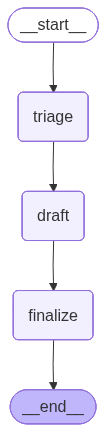

In [6]:
from IPython.display import Image, display

# Show workflow
display(Image(persistence_graph.get_graph().draw_mermaid_png()))


Store long-term prefs in a namespace; load_preferences reads them via get_store(). DATAFLOW summary should mention beach budget and Star Alliance loyalty text.


STORE namespace: ('traveler-7', 'travel_preferences')


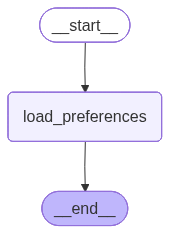

DATAFLOW
0. input: {'summary': ''}
1. load_preferences: {'summary': 'prefers beach destinations under $600; loyalty:Star Alliance'}
2. final: {'summary': 'prefers beach destinations under $600; loyalty:Star Alliance'}


{'summary': 'prefers beach destinations under $600; loyalty:Star Alliance'}

In [7]:
from langgraph.store.memory import InMemoryStore
from langgraph.config import get_store
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

store = InMemoryStore()
NS = ("traveler-7", "travel_preferences")
store.put(NS, "budget", {"text": "prefers beach destinations under $600"})
store.put(NS, "airline", {"text": "loyalty:Star Alliance"})
print("STORE namespace:", NS)

class PrefState(TypedDict):
    summary: str

def load_preferences(_: PrefState):
    items = get_store().search(NS, limit=10)
    return {"summary": "; ".join(i.value.get("text", "") for i in items)}

g = StateGraph(PrefState)
g.add_node("load_preferences", load_preferences)
g.add_edge(START, "load_preferences")
g.add_edge("load_preferences", END)
store_graph = g.compile(store=store)

from IPython.display import Image, display

display(Image(store_graph.get_graph().draw_mermaid_png()))
print_dataflow(store_graph, {"summary": ""})


Define hitl_graph with interrupt() inside book_trip and compile with InMemorySaver. This graph pauses until a human approves, inspect the single book_trip node.


In [11]:
from typing import TypedDict
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt

class BookingState(TypedDict):
    destination: str
    budget: int
    status: str

def book_trip(state: BookingState):
    # LangGraph built-in: first call pauses; Command(resume=...) value returns here
    human_decision = interrupt({
        "action": "book_trip",
        "destination": state["destination"],
        "budget": state["budget"],
        "message": f"Approve booking {state['destination']} for ${state['budget']}?",
    })
    approved = human_decision.get("approved", False) if isinstance(human_decision, dict) else bool(human_decision)
    if approved:
        return {"status": f"BOOKED {state['destination']}"}
    return {"status": "CANCELLED"}

checkpointer = InMemorySaver()
hitl_builder = StateGraph(BookingState)
hitl_builder.add_node("book_trip", book_trip)
hitl_builder.add_edge(START, "book_trip")
hitl_builder.add_edge("book_trip", END)
hitl_graph = hitl_builder.compile(checkpointer=checkpointer)


Visualize hitl_graph, one node, one interrupt point.


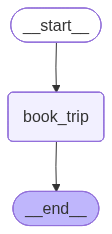

In [12]:
from IPython.display import Image, display

# Show workflow
display(Image(hitl_graph.get_graph().draw_mermaid_png()))


Stream until interrupt() pauses the run. Look for __interrupt__ in stream output and next nodes showing book_trip still pending.


In [15]:

config = {"configurable": {"thread_id": "booking-approval-1"}}
inputs = {"destination": "Lisbon", "budget": 480, "status": ""}

print("REAL-TIME HITL, stream until interrupt()")
for chunk in hitl_graph.stream(inputs, config=config):
    print(f" stream: {preview(chunk)}")

snap = hitl_graph.get_state(config)
print(f"\nCHECKPOINT (graph paused)")
print(f" next nodes: {snap.next}")
print(f" state: {preview(snap.values)}")
print(f" interrupts: {preview(snap.interrupts[0].value if snap.interrupts else None)}")


REAL-TIME HITL, stream until interrupt()
 stream: {'__interrupt__': (Interrupt(value={'action': 'book_trip', 'destination': 'Lisbon', 'budget': 480, 'message': 'Approve booking Lisbon for $480?'}, id='7d3c3db6869284d410809d4dbeeb2...

CHECKPOINT (graph paused)
 next nodes: ('book_trip',)
 state: {'destination': 'Lisbon', 'budget': 480, 'status': ''}
 interrupts: {'action': 'book_trip', 'destination': 'Lisbon', 'budget': 480, 'message': 'Approve booking Lisbon for $480?'}


After pause, ask_approval collects your y/n, then Command(resume=...) finishes the booking. FINAL STATE status should read BOOKED Lisbon or CANCELLED based on your answer.


In [16]:
from langgraph.types import Command

config = {"configurable": {"thread_id": "booking-approval-1"}}
snap = hitl_graph.get_state(config)
payload = snap.interrupts[0].value

print("REAL-TIME HITL, wait for human, then stream resume")
human_decision = ask_approval(payload)

for chunk in hitl_graph.stream(Command(resume=human_decision), config=config):
    print(f" stream: {preview(chunk)}")

print_final_state(hitl_graph.get_state(config).values, keys=["destination", "budget", "status"])


REAL-TIME HITL, wait for human, then stream resume
HUMAN REVIEW
  action: book_trip
  destination: Lisbon
  budget: 480
  message: Approve booking Lisbon for $480?
 stream: {'book_trip': {'status': 'BOOKED Lisbon'}}
FINAL STATE
  destination: Lisbon
  budget: 480
  status: BOOKED Lisbon


**Time travel** lets you rewind a persisted thread, edit state at an earlier checkpoint, and resume from there.

Three ideas to keep straight:

1. **`thread_id`** — checkpoints are grouped per thread (same `config` as earlier cells).
2. **`get_state_history(config)`** — snapshots after each node; read them to see where you are in the run.
3. **`update_state(..., as_node="step_a")`** — rewind to the checkpoint *after* `step_a`, patch fields, then **`invoke(None, fork_config)`** to re-run downstream nodes.

The toy graph below is `step_a` (mark searched) → `step_b` (draft using `destination`). We run it for Lisbon, rewind to `step_a`, change destination to Porto, and resume so `step_b` drafts for Porto.


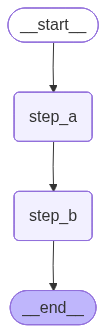

In [20]:
from typing import TypedDict
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

class TTState(TypedDict):
    destination: str
    status: str

g = StateGraph(TTState)
g.add_node("step_a", lambda s: {"status": "searched"})
g.add_node("step_b", lambda s: {"status": f"drafted for {s['destination']}"})
g.add_edge(START, "step_a")
g.add_edge("step_a", "step_b")
g.add_edge("step_b", END)
time_travel_graph = g.compile(checkpointer=InMemorySaver())

config = {"configurable": {"thread_id": "time-travel-1"}}
inputs = {"destination": "Lisbon", "status": ""}

display(Image(time_travel_graph.get_graph().draw_mermaid_png()))


**Step 1 — Run once and read the checkpoint trail.** Each row is state saved after a node. Notice `step_b` reads `destination` from the prior checkpoint.


In [23]:
final = time_travel_graph.invoke(inputs, config)
print("FINAL STATE:", final)

history = list(time_travel_graph.get_state_history(config))
print(f"\nCHECKPOINTS ({len(history)} snapshots, oldest first):")
for i, snap in enumerate(reversed(history)):
    v = snap.values
    print(
        f"  [{i}] next={snap.next} "
        f"destination={v.get('destination', '')!r} status={v.get('status', '')!r}"
    )


FINAL STATE: {'destination': 'Lisbon', 'status': 'drafted for Lisbon'}

CHECKPOINTS (10 snapshots, oldest first):
  [0] next=('__start__',) destination='' status=''
  [1] next=('step_a',) destination='Lisbon' status=''
  [2] next=('step_b',) destination='Lisbon' status='searched'
  [3] next=() destination='Lisbon' status='drafted for Lisbon'
  [4] next=('step_b',) destination='Porto' status='drafted for Lisbon'
  [5] next=() destination='Porto' status='drafted for Porto'
  [6] next=('__start__',) destination='Porto' status='drafted for Porto'
  [7] next=('step_a',) destination='Lisbon' status=''
  [8] next=('step_b',) destination='Lisbon' status='searched'
  [9] next=() destination='Lisbon' status='drafted for Lisbon'


**Step 2 — Rewind, patch, resume.** `update_state` only edits the forked snapshot (you may still see the old `status` until downstream nodes re-run). Pass the returned `fork_config` to `invoke(None, ...)` so `step_b` runs again with Porto.


In [24]:
fork_config = time_travel_graph.update_state(
    config,
    {"destination": "Porto"},
    as_node="step_a",
)
forked = time_travel_graph.get_state(fork_config).values
print("FORKED (patched, before resume):", forked)
print("  note: status still says Lisbon until step_b re-runs")

resumed = time_travel_graph.invoke(None, fork_config)
print("RESUMED (after step_b re-runs):", resumed)


FORKED (patched, before resume): {'destination': 'Porto', 'status': 'drafted for Lisbon'}
  note: status still says Lisbon until step_b re-runs
RESUMED (after step_b re-runs): {'destination': 'Porto', 'status': 'drafted for Porto'}
